# Base Strategy Walkthrough

This notebook demonstrates the execution strategy framework. All logic lives in `utils/`:

| Module | What it does |
|--------|-------------|
| `config.py` | Default experiment settings (grid ranges, train/test split, etc.) |
| `preprocessing.py` | Load CSVs, detect penny vs. wide archetype, compute TWAP |
| `signals.py` | Pluggable signal functions (OI, weighted OI, etc.) + diagnostic plots |
| `strategy.py` | `BaseStrategy` class, grid search, `run_experiment()` one-liner |
| `evaluation.py` | Backtest harness, results tables, `compare_strategies()` |

**To add a new strategy:** subclass `BaseStrategy`, implement `decide()`, and call `run_experiment()`. See Section 4 for an example.

## 1. Setup & Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.config import DEFAULT_CONFIG
from utils.preprocessing import load_all_stocks, train_test_split
from utils.signals import add_horizon_columns, plot_edge_vs_imbalance
from utils.strategy import OIThresholdStrategy, run_experiment
from utils.evaluation import print_results, plot_results, compare_strategies

config = DEFAULT_CONFIG.copy()

data, frames, archetypes = load_all_stocks(config)

print(f"Total ticks: {len(data):,}")
for t in config['stocks']:
    n = data.loc[data['ticker'] == t, 'minute_start'].nunique()
    med = frames[t]['spread'].median()
    print(f"  {t}: {archetypes[t]:6s}  ({n} min, median spread = ${med:.4f})")

Total ticks: 1,149,529
  INTC: penny   (270 min, median spread = $0.0100)
  MSFT: penny   (270 min, median spread = $0.0100)
  AMZN: wide    (270 min, median spread = $0.1400)
  GOOG: wide    (270 min, median spread = $0.3000)


## 2. Signal Analysis

Does OI predict future price movement? Plot mean mid-price change vs. OI at multiple horizons.

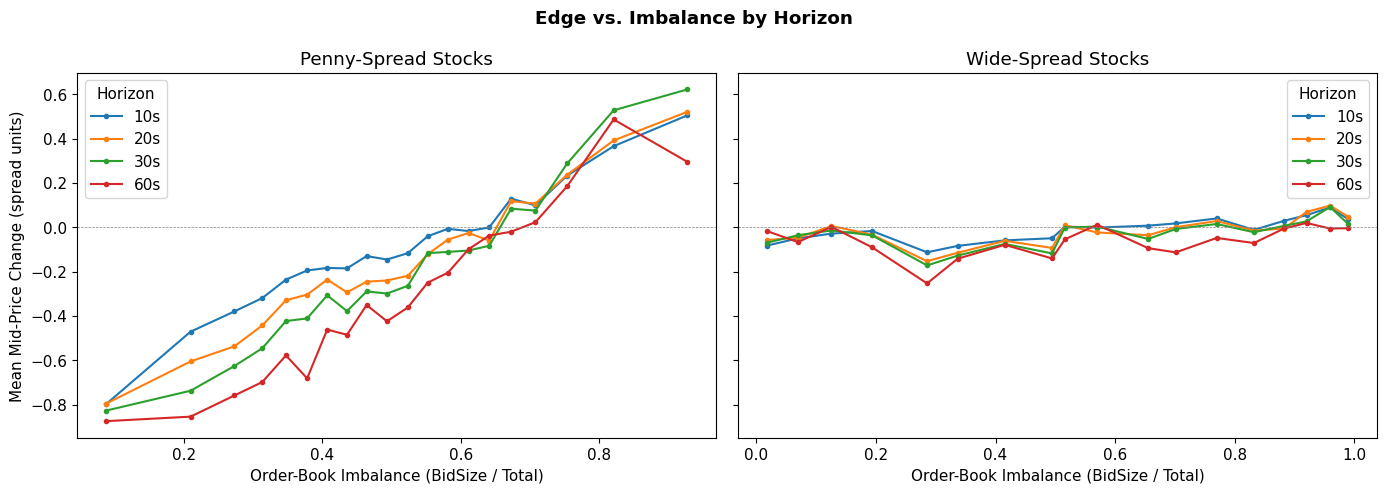

In [2]:
add_horizon_columns(data, config)
plot_edge_vs_imbalance(data, config)

## 3. Run the Base Strategy (OI Threshold)

`run_experiment()` handles everything: load data, fit parameters via grid search, backtest on held-out data.

In [3]:
oi_results = run_experiment(OIThresholdStrategy, config, signal_fn='oi')

Running experiment: OI Threshold (signal=oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
    penny/open: theta_imb=0.9500, theta_spread=0.0116
    penny/mid: theta_imb=0.9500, theta_spread=0.0116
    wide/open: theta_imb=0.6016, theta_spread=0.3342
    wide/mid: theta_imb=0.5497, theta_spread=0.1566
  Backtesting...


Mean Improvement over TWAP ($)
  Penny  (n= 324, win_rate=77.2%)  OI Threshold: $+0.005634  First Tick: $+0.000695  Last Tick: $+0.000695
  Wide   (n= 324, win_rate=62.7%)  OI Threshold: $+0.039705  First Tick: $+0.004427  Last Tick: $+0.004828
  All    (n= 648, win_rate=69.9%)  OI Threshold: $+0.022669  First Tick: $+0.002561  Last Tick: $+0.002762

Mean Improvement (spread units)

  Penny (median spread = $0.0100):
    OI Threshold        : +0.5634 spread units
    First Tick          : +0.0695 spread units
    Last Tick           : +0.0695 spread units

  Wide (median spread = $0.1600):
    OI Threshold        : +0.2482 spread units
    First Tick          : +0.0277 spread units
    Last Tick           : +0.0302 spread units


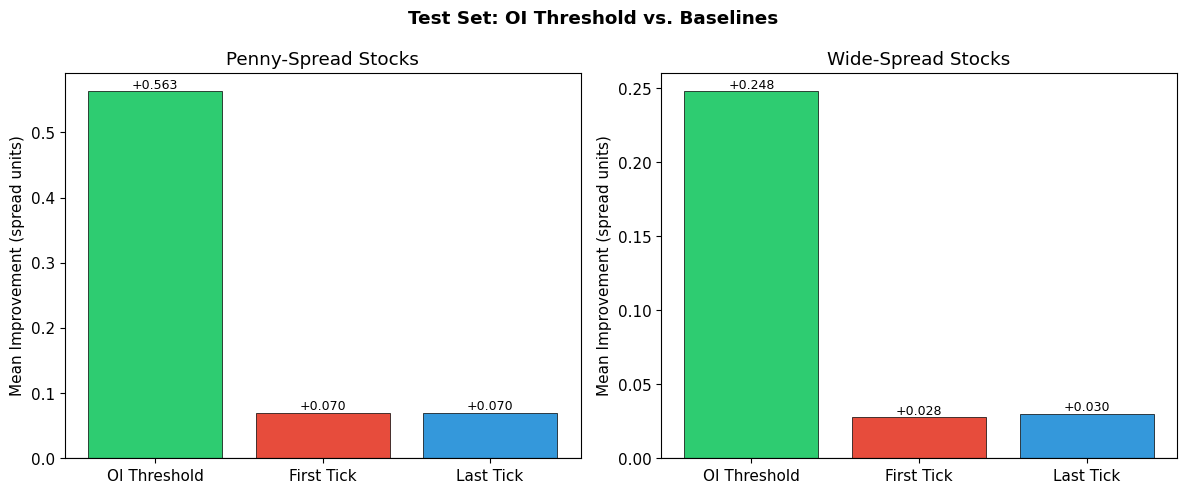

In [4]:
print_results(oi_results['test_all'], strategy_name='OI Threshold')
plot_results(oi_results['test_all'], strategy_name='OI Threshold')

## 4. How to Add a New Strategy

Subclass `BaseStrategy`, implement `decide()` and `param_grid()`, then call `run_experiment()`. Here's an example using the **weighted 5-level OI** signal instead of level-1 OI:

In [5]:
# Same strategy logic, just swap the signal to weighted 5-level OI
weighted_results = run_experiment(OIThresholdStrategy, config, signal_fn='weighted_oi')

Running experiment: OI Threshold (signal=weighted_oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
    penny/open: theta_imb=0.6016, theta_spread=0.0116
    penny/mid: theta_imb=0.5719, theta_spread=0.0116
    wide/open: theta_imb=0.5200, theta_spread=0.3342
    wide/mid: theta_imb=0.5793, theta_spread=0.1566
  Backtesting...


## 5. Compare Strategies

`compare_strategies()` puts multiple experiment results side by side — mean improvement, std, win rate — with a bar chart.

STRATEGY COMPARISON

  Penny:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    OI (level 1)                   +0.5634       0.5791      77.2%
    Weighted OI (5-level)          +0.4029       0.7109      66.4%

  Wide:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    OI (level 1)                   +0.2482       0.6678      62.7%
    Weighted OI (5-level)          +0.1664       0.6544      55.9%

  All:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    OI (level 1)                   +0.5038       1.7223      69.9%
    Weighted OI (5-level)          +0.3405       1.6668      61.1%


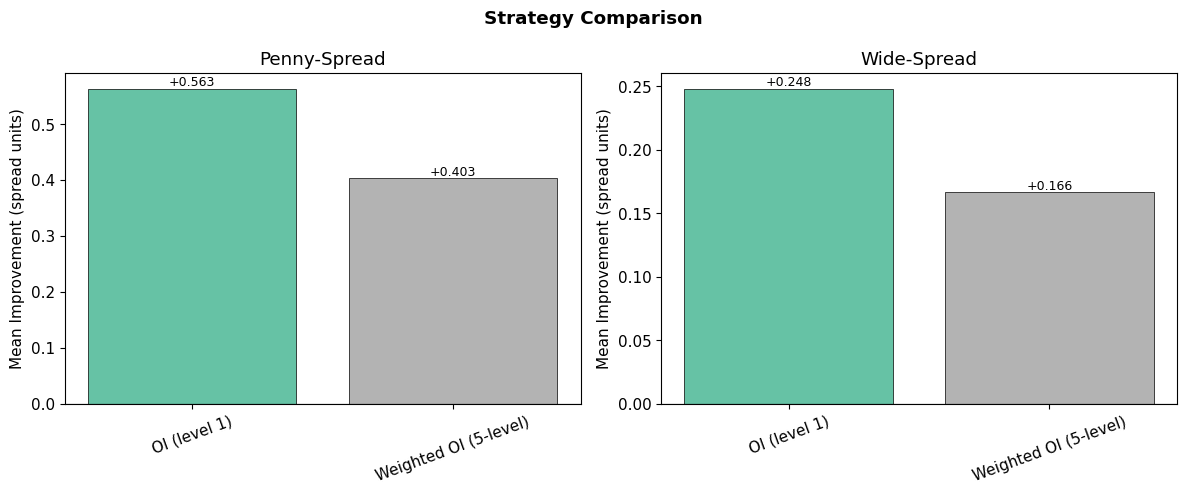

In [6]:
comparison = compare_strategies([
    ('OI (level 1)', oi_results),
    ('Weighted OI (5-level)', weighted_results),
])

## Quick Reference: Adding Your Own Strategy

```python
from utils.strategy import BaseStrategy, run_experiment
from utils.config import DEFAULT_CONFIG
import numpy as np

class MyStrategy(BaseStrategy):
    name = 'My Strategy'

    def decide(self, signal, spread, side):
        """Return tick index to execute, or None for last-tick fallback."""
        for i in range(len(signal)):
            if signal[i] > self.params['my_threshold']:
                return i
        return None

    @classmethod
    def param_grid(cls, archetype):
        return {'my_threshold': np.linspace(0.5, 0.95, 20)}

results = run_experiment(MyStrategy, DEFAULT_CONFIG, signal_fn='oi')
```

To add a new **signal**, add a function to `utils/signals.py` and register it in `SIGNAL_REGISTRY`.